Sử dụng thuật toán SOLOMON để chia training set và test set

In [1]:
import numpy as np
from solomon import solomon_split
from kfold import kfold_linear_1d, kfold_linear_2d, kfold_linear_3d, kfold_linear_4d, kfold_linear_8d  # từ kfold.py đã tạo

# --- DỮ LIỆU CỦA BẠN ---
x_train = np.array([
    2, 3, 4, 5, 6, 8, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 
    60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 120, 130, 
    140, 150, 160, 170, 180, 190, 200, 220, 240, 260, 280, 
    300, 320, 340, 360, 370, 375, 380
], dtype=float)

y_train = np.array([
    2.782325, 3.25935, 4.067545, 5.04757, 6.001975, 8.326895, 
    10.236335, 15.23321, 19.16292, 23.82822, 28.634885, 33.47087, 
    38.24309, 43.087885, 47.57985, 52.06106, 56.979895, 61.867765, 
    66.620375, 71.474615, 76.4032, 81.338595, 85.72017, 90.860385, 
    95.48461, 100.976285, 104.3609942, 115.81523, 125.367865, 
    135.302295, 145.42794, 156.20736, 165.91558, 175.484755, 
    185.44674, 195.15566, 214.725685, 234.09771, 254.23034, 
    273.649395, 293.15766, 311.469805, 332.2342118, 350.567955, 
    361.148005, 365.54858, 370.504295
], dtype=float)


In [2]:
X = np.column_stack([x_train, y_train])

split = solomon_split(X, test_ratio=0.2, seed=42, max_iter=2000)
train_idx, test_idx = split["idx_A"], split["idx_B"]   # idx_B có kích thước ≈ 20%

x_tr, y_tr = x_train[train_idx], y_train[train_idx]
x_te, y_te = x_train[test_idx], y_train[test_idx]

print("SOLOMON diagnostics:",
      {k: split[k] for k in ["corr_frobenius","kmo_A","kmo_B","S_A","S_B"]})
print(x_tr)
print(y_tr)
print(x_te)
print(y_te)


SOLOMON diagnostics: {'corr_frobenius': 4.055145447290369e-05, 'kmo_A': 0.5000000000000001, 'kmo_B': 0.5, 'S_A': 13471.313769832279, 'S_B': 13479.352822717321}
[  2.   4.   5.   8.  10.  15.  20.  25.  30.  40.  45.  50.  55.  60.
  65.  70.  75.  80.  85.  90.  95. 100. 105. 110. 120. 130. 140. 150.
 160. 170. 180. 260. 320. 340. 360. 370. 375. 380.]
[  2.782325    4.067545    5.04757     8.326895   10.236335   15.23321
  19.16292    23.82822    28.634885   38.24309    43.087885   47.57985
  52.06106    56.979895   61.867765   66.620375   71.474615   76.4032
  81.338595   85.72017    90.860385   95.48461   100.976285  104.3609942
 115.81523   125.367865  135.302295  145.42794   156.20736   165.91558
 175.484755  254.23034   311.469805  332.2342118 350.567955  361.148005
 365.54858   370.504295 ]
[  3.   6.  35. 190. 200. 220. 240. 280. 300.]
[  3.25935    6.001975  33.47087  185.44674  195.15566  214.725685
 234.09771  273.649395 293.15766 ]


## 1. Kiểm tra MAE, MSE, R2 khi dùng hàm số bậc nhất


===== Fold 1 =====
x_val: [160. 360.  85.  45. 110. 140. 370.  75.  20. 130. 180.  95.  40. 260.
  90.   8.   2.  70.  80. 320.  55. 100.  50.  65. 375.   5. 340.   4.
  60.  30.]
y_val: [156.20736   350.567955   81.338595   43.087885  104.3609942 135.302295
 361.148005   71.474615   19.16292   125.367865  175.484755   90.860385
  38.24309   254.23034    85.72017     8.326895    2.782325   66.620375
  76.4032    311.469805   52.06106    95.48461    47.57985    61.867765
 365.54858     5.04757   332.2342118   4.067545   56.979895   28.634885 ]
Iteration    0: Cost 6.35e+03  dj_dw: -1.138e+02, dj_db:  8.527e-15   w:  1.138e+00, b:-8.52651e-17
Iteration 1000: Cost 4.27e-01  dj_dw: -4.914e-03, dj_db:  1.303e-15   w:  1.138e+02, b:-6.18350e-15
Iteration 2000: Cost 4.27e-01  dj_dw: -2.121e-07, dj_db: -1.480e-16   w:  1.138e+02, b:-6.28653e-15
Iteration 3000: Cost 4.27e-01  dj_dw: -9.151e-12, dj_db: -1.421e-15   w:  1.138e+02, b:-6.23975e-15
Iteration 4000: Cost 4.27e-01  dj_dw: -7.081e-13, 

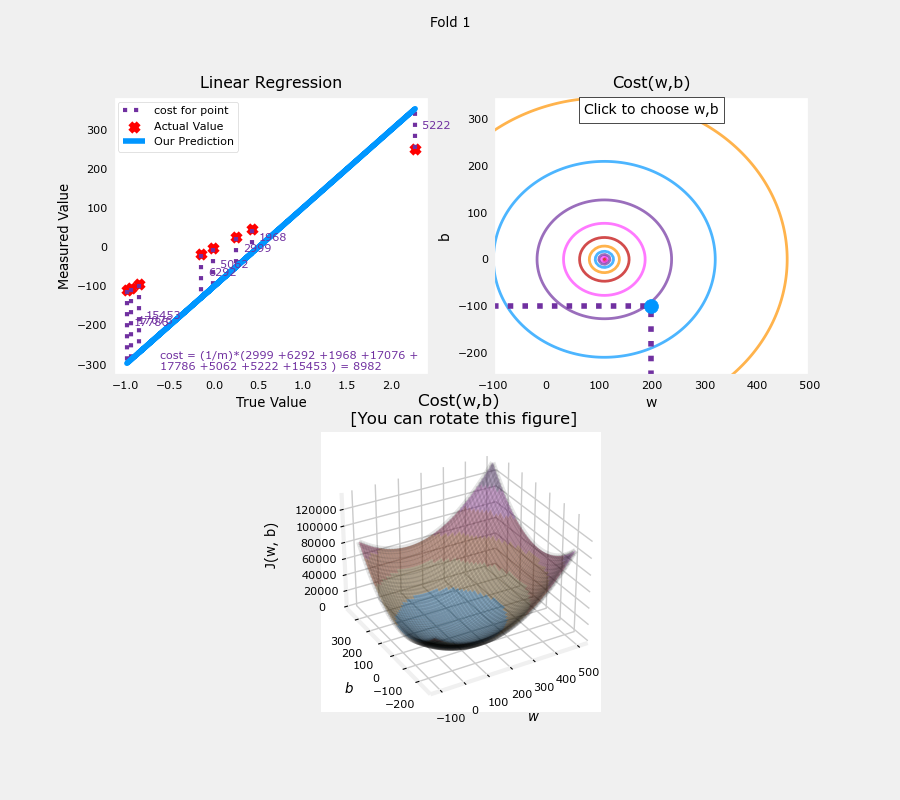


===== Fold 2 =====
x_val: [150. 105. 170.  15.  10. 120. 380.  25.  20. 130. 180.  95.  40. 260.
  90.   8.   2.  70.  80. 320.  55. 100.  50.  65. 375.   5. 340.   4.
  60.  30.]
y_val: [145.42794   100.976285  165.91558    15.23321    10.236335  115.81523
 370.504295   23.82822    19.16292   125.367865  175.484755   90.860385
  38.24309   254.23034    85.72017     8.326895    2.782325   66.620375
  76.4032    311.469805   52.06106    95.48461    47.57985    61.867765
 365.54858     5.04757   332.2342118   4.067545   56.979895   28.634885 ]
Iteration    0: Cost 5.88e+03  dj_dw: -1.095e+02, dj_db:  2.842e-15   w:  1.095e+00, b:-2.84217e-17
Iteration 1000: Cost 3.95e-01  dj_dw: -4.728e-03, dj_db:  1.243e-15   w:  1.095e+02, b:-7.08678e-15
Iteration 2000: Cost 3.95e-01  dj_dw: -2.041e-07, dj_db:  1.391e-15   w:  1.095e+02, b:-7.09122e-15
Iteration 3000: Cost 3.95e-01  dj_dw: -8.813e-12, dj_db:  2.072e-16   w:  1.095e+02, b:-7.07730e-15
Iteration 4000: Cost 3.95e-01  dj_dw: -6.966e-13, d

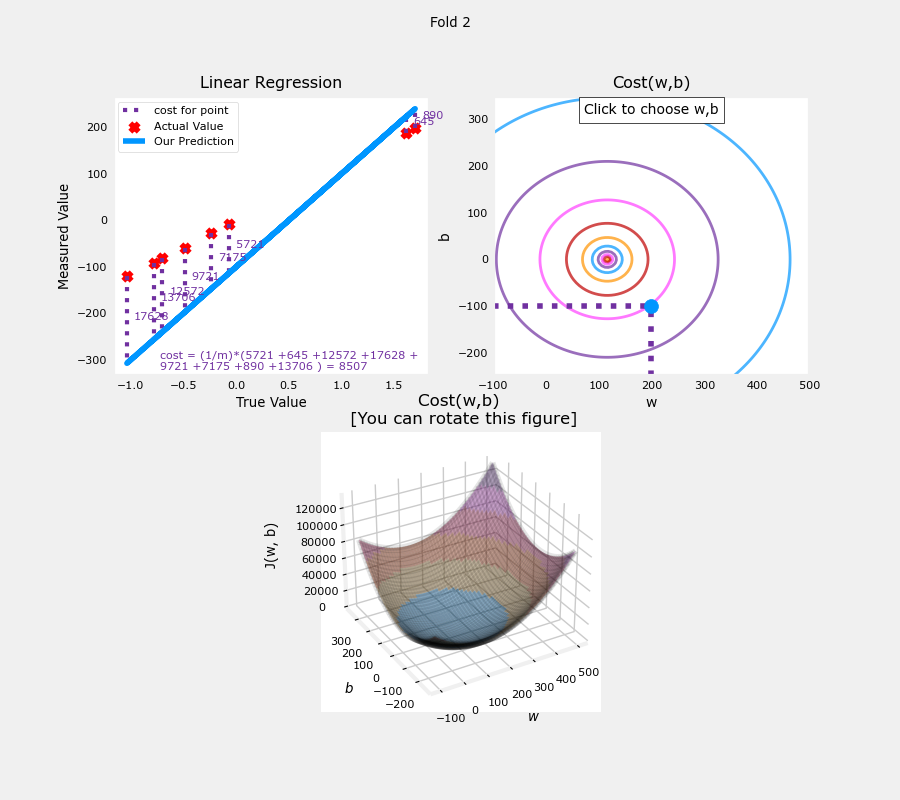


===== Fold 3 =====
x_val: [150. 105. 170.  15.  10. 120. 380.  25. 160. 360.  85.  45. 110. 140.
 370.  75.   2.  70.  80. 320.  55. 100.  50.  65. 375.   5. 340.   4.
  60.  30.]
y_val: [145.42794   100.976285  165.91558    15.23321    10.236335  115.81523
 370.504295   23.82822   156.20736   350.567955   81.338595   43.087885
 104.3609942 135.302295  361.148005   71.474615    2.782325   66.620375
  76.4032    311.469805   52.06106    95.48461    47.57985    61.867765
 365.54858     5.04757   332.2342118   4.067545   56.979895   28.634885 ]
Iteration    0: Cost 7.08e+03  dj_dw: -1.202e+02, dj_db: -9.474e-15   w:  1.202e+00, b: 9.47390e-17
Iteration 1000: Cost 4.07e-01  dj_dw: -5.189e-03, dj_db: -1.776e-16   w:  1.202e+02, b:-3.83812e-15
Iteration 2000: Cost 4.07e-01  dj_dw: -2.240e-07, dj_db:  0.000e+00   w:  1.202e+02, b:-4.20878e-15
Iteration 3000: Cost 4.07e-01  dj_dw: -9.693e-12, dj_db:  9.474e-16   w:  1.202e+02, b:-4.25082e-15
Iteration 4000: Cost 4.07e-01  dj_dw: -6.966e-13, d

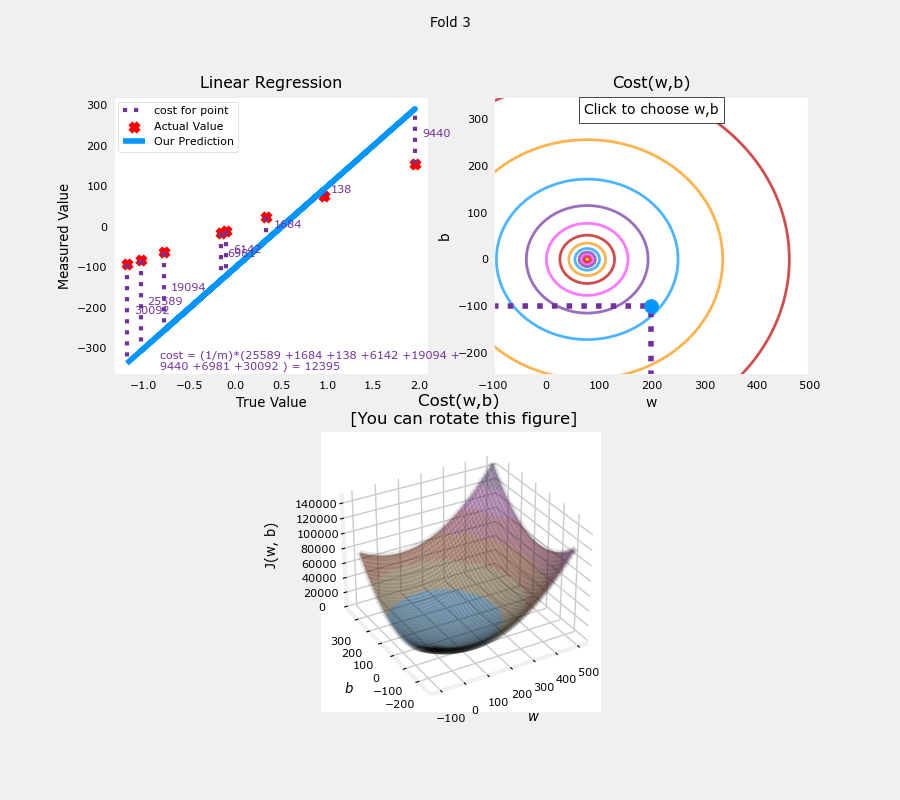


===== Fold 4 =====
x_val: [150. 105. 170.  15.  10. 120. 380.  25. 160. 360.  85.  45. 110. 140.
 370.  75.  20. 130. 180.  95.  40. 260.  90.   8.  65. 375.   5. 340.
   4.  60.  30.]
y_val: [145.42794   100.976285  165.91558    15.23321    10.236335  115.81523
 370.504295   23.82822   156.20736   350.567955   81.338595   43.087885
 104.3609942 135.302295  361.148005   71.474615   19.16292   125.367865
 175.484755   90.860385   38.24309   254.23034    85.72017     8.326895
  61.867765  365.54858     5.04757   332.2342118   4.067545   56.979895
  28.634885 ]
Iteration    0: Cost 6.64e+03  dj_dw: -1.164e+02, dj_db:  8.251e-15   w:  1.164e+00, b:-8.25146e-17
Iteration 1000: Cost 3.96e-01  dj_dw: -5.026e-03, dj_db:  3.008e-16   w:  1.164e+02, b:-7.08021e-15
Iteration 2000: Cost 3.96e-01  dj_dw: -2.170e-07, dj_db:  2.435e-16   w:  1.164e+02, b:-7.05987e-15
Iteration 3000: Cost 3.96e-01  dj_dw: -9.367e-12, dj_db:  7.163e-17   w:  1.164e+02, b:-7.08996e-15
Iteration 4000: Cost 3.96e-01  dj_

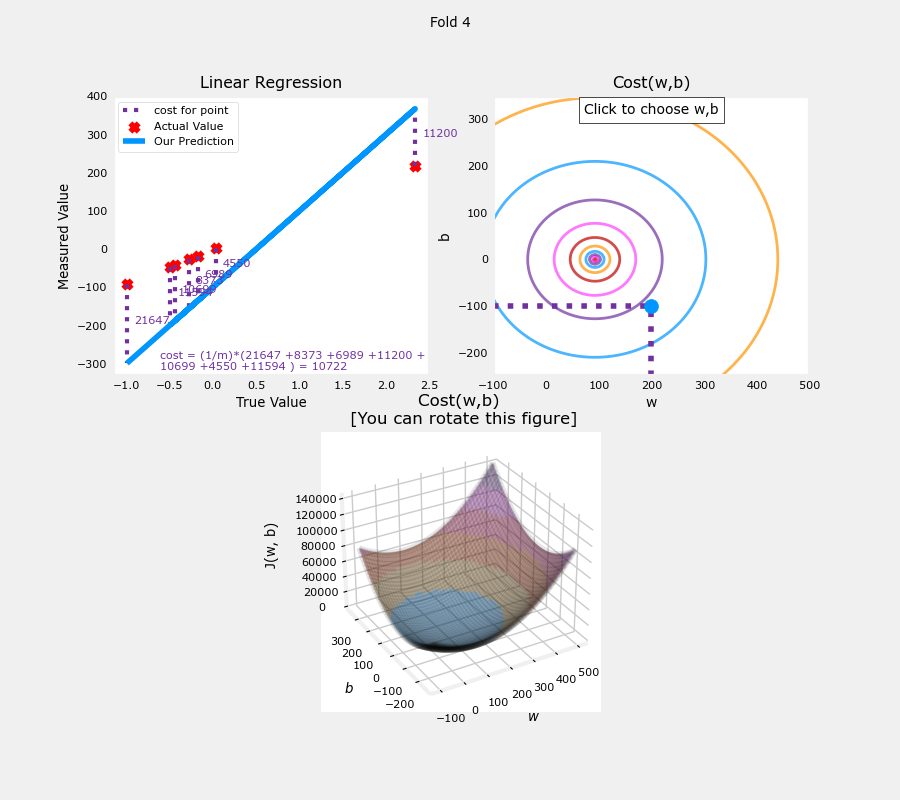


===== Fold 5 =====
x_val: [150. 105. 170.  15.  10. 120. 380.  25. 160. 360.  85.  45. 110. 140.
 370.  75.  20. 130. 180.  95.  40. 260.  90.   8.   2.  70.  80. 320.
  55. 100.  50.]
y_val: [145.42794   100.976285  165.91558    15.23321    10.236335  115.81523
 370.504295   23.82822   156.20736   350.567955   81.338595   43.087885
 104.3609942 135.302295  361.148005   71.474615   19.16292   125.367865
 175.484755   90.860385   38.24309   254.23034    85.72017     8.326895
   2.782325   66.620375   76.4032    311.469805   52.06106    95.48461
  47.57985  ]
Iteration    0: Cost 5.36e+03  dj_dw: -1.046e+02, dj_db:  2.200e-14   w:  1.046e+00, b:-2.20039e-16
Iteration 1000: Cost 4.36e-01  dj_dw: -4.515e-03, dj_db:  1.347e-15   w:  1.046e+02, b:-2.42650e-14
Iteration 2000: Cost 4.36e-01  dj_dw: -1.949e-07, dj_db:  7.736e-16   w:  1.046e+02, b:-2.48581e-14
Iteration 3000: Cost 4.36e-01  dj_dw: -8.440e-12, dj_db:  3.152e-16   w:  1.046e+02, b:-2.48332e-14
Iteration 4000: Cost 4.36e-01  dj_d

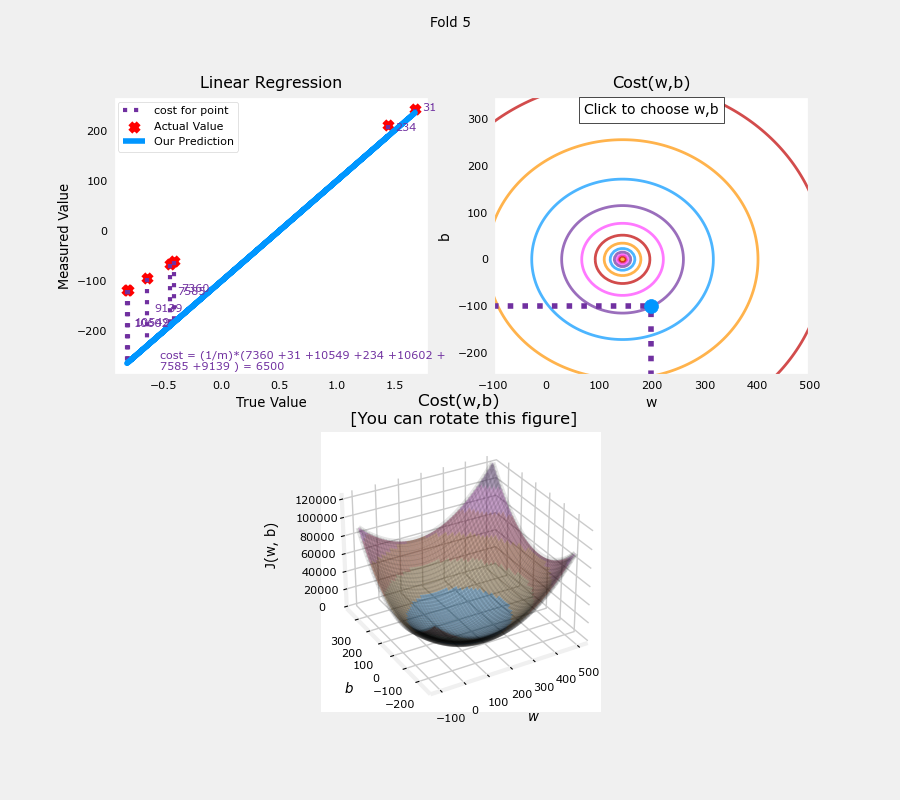

{'folds': [{'fold': 1, 'w': np.float64(0.9775008358297188), 'b': np.float64(-1.0849103876624326), 'MSE': np.float64(0.8204227613297055), 'MAE': np.float64(0.7162897142047631), 'R2': np.float64(0.9999331233439632), 'x_val': array([150., 105., 170.,  15.,  10., 120., 380.,  25.]), 'y_val': array([145.42794 , 100.976285, 165.91558 ,  15.23321 ,  10.236335,
       115.81523 , 370.504295,  23.82822 ])}, {'fold': 2, 'w': np.float64(0.9763705246733508), 'b': np.float64(-0.7543849318139451), 'MSE': np.float64(1.0546449707365961), 'MAE': np.float64(0.8088857005811523), 'R2': np.float64(0.9999219652667991), 'x_val': array([160., 360.,  85.,  45., 110., 140., 370.,  75.]), 'y_val': array([156.20736  , 350.567955 ,  81.338595 ,  43.087885 , 104.3609942,
       135.302295 , 361.148005 ,  71.474615 ])}, {'fold': 3, 'w': np.float64(0.9768178527493787), 'b': np.float64(-0.9313173752197343), 'MSE': np.float64(0.9054243214327375), 'MAE': np.float64(0.854546146226181), 'R2': np.float64(0.9998526794601926

In [3]:
%matplotlib widget
result = kfold_linear_1d(
    x_tr, y_tr,
    k=5,
    verbose=True,
    interactive=True,
    save_dir="fold_plots"   # tùy chọn
)
print(result)

Hàm bậc cao

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from multi_polynomial import zscore_normalize_features, run_gradient_descent_feng
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
result = kfold_linear_2d(
    x_tr, y_tr,
    k=5,
    verbose=True,
    interactive = True,
    save_dir="fold_plots"   # tùy chọn
)
print(result)


===== Fold 1 =====
x_val: [160. 360.  85.  45. 110. 140. 370.  75.  20. 130. 180.  95.  40. 260.
  90.   8.   2.  70.  80. 320.  55. 100.  50.  65. 375.   5. 340.   4.
  60.  30.]
y_val: [156.21 350.57  81.34  43.09 104.36 135.3  361.15  71.47  19.16 125.37
 175.48  90.86  38.24 254.23  85.72   8.33   2.78  66.62  76.4  311.47
  52.06  95.48  47.58  61.87 365.55   5.05 332.23   4.07  56.98  28.63]
Coefficients: [9.60e-01 4.58e-05]
Intercept: -0.2658096520884925
Hàm hồi quy: y = -0.266 + 0.960*x + 0.000*x²
Fold 1 | MSE=0.698117 | MAE=0.662685 | R2=0.999943

===== Fold 2 =====
x_val: [150. 105. 170.  15.  10. 120. 380.  25.  20. 130. 180.  95.  40. 260.
  90.   8.   2.  70.  80. 320.  55. 100.  50.  65. 375.   5. 340.   4.
  60.  30.]
y_val: [145.43 100.98 165.92  15.23  10.24 115.82 370.5   23.83  19.16 125.37
 175.48  90.86  38.24 254.23  85.72   8.33   2.78  66.62  76.4  311.47
  52.06  95.48  47.58  61.87 365.55   5.05 332.23   4.07  56.98  28.63]
Coefficients: [9.61e-01 4.25e-05]
I

In [6]:
result = kfold_linear_3d(
    x_tr, y_tr,
    k=5,
    verbose=True,
    interactive=True,
    save_dir="fold_plots"   # tùy chọn
)
print(result)


===== Fold 1 =====
x_val: [160. 360.  85.  45. 110. 140. 370.  75.  20. 130. 180.  95.  40. 260.
  90.   8.   2.  70.  80. 320.  55. 100.  50.  65. 375.   5. 340.   4.
  60.  30.]
y_val: [156.21 350.57  81.34  43.09 104.36 135.3  361.15  71.47  19.16 125.37
 175.48  90.86  38.24 254.23  85.72   8.33   2.78  66.62  76.4  311.47
  52.06  95.48  47.58  61.87 365.55   5.05 332.23   4.07  56.98  28.63]
Coefficients: [ 9.22e-01  3.61e-04 -6.08e-07]
Intercept: 0.5981999649645786
Hàm hồi quy: y = 0.598 + 0.922*x + 0.000*x² + -0.000*x³
Fold 1 | MSE=0.323336 | MAE=0.486525 | R2=0.999974

===== Fold 2 =====
x_val: [150. 105. 170.  15.  10. 120. 380.  25.  20. 130. 180.  95.  40. 260.
  90.   8.   2.  70.  80. 320.  55. 100.  50.  65. 375.   5. 340.   4.
  60.  30.]
y_val: [145.43 100.98 165.92  15.23  10.24 115.82 370.5   23.83  19.16 125.37
 175.48  90.86  38.24 254.23  85.72   8.33   2.78  66.62  76.4  311.47
  52.06  95.48  47.58  61.87 365.55   5.05 332.23   4.07  56.98  28.63]
Coefficients:

Có thể thấy khi nâng bậc lên, các hệ số bậc khác 1 có giá trị gần như bằng 0.
Dùng hàm bậc cao nhất có thể (ở đây là bậc 8) đi qua tất cả các điểm trong dataset. Đương nhiên dễ dẫn đến overfitting

In [7]:
result = kfold_linear_4d(
    x_tr, y_tr,
    k=5,
    verbose=True,
    interactive=True,
    save_dir="fold_plots"   # tùy chọn
)
print(result)


===== Fold 1 =====
x_val: [160. 360.  85.  45. 110. 140. 370.  75.  20. 130. 180.  95.  40. 260.
  90.   8.   2.  70.  80. 320.  55. 100.  50.  65. 375.   5. 340.   4.
  60.  30.]
y_val: [156.21 350.57  81.34  43.09 104.36 135.3  361.15  71.47  19.16 125.37
 175.48  90.86  38.24 254.23  85.72   8.33   2.78  66.62  76.4  311.47
  52.06  95.48  47.58  61.87 365.55   5.05 332.23   4.07  56.98  28.63]
Coefficients: [ 8.97e-01  7.30e-04 -2.29e-06  2.34e-09]
Intercept: 0.9242437567111921
Hàm hồi quy: y = 0.924 + 0.897*x + 0.001*x² + -0.000*x^3 + 0.000*x^4
Fold 1 | MSE=0.137538 | MAE=0.272452 | R2=0.999989

===== Fold 2 =====
x_val: [150. 105. 170.  15.  10. 120. 380.  25.  20. 130. 180.  95.  40. 260.
  90.   8.   2.  70.  80. 320.  55. 100.  50.  65. 375.   5. 340.   4.
  60.  30.]
y_val: [145.43 100.98 165.92  15.23  10.24 115.82 370.5   23.83  19.16 125.37
 175.48  90.86  38.24 254.23  85.72   8.33   2.78  66.62  76.4  311.47
  52.06  95.48  47.58  61.87 365.55   5.05 332.23   4.07  56.9

In [8]:
result = kfold_linear_8d(
    x_tr, y_tr,
    k=5,
    verbose=True,
    interactive=True,
    save_dir="fold_plots"   # tùy chọn
)
print(result)


===== Fold 1 =====
x_val: [160. 360.  85.  45. 110. 140. 370.  75.  20. 130. 180.  95.  40. 260.
  90.   8.   2.  70.  80. 320.  55. 100.  50.  65. 375.   5. 340.   4.
  60.  30.]
y_val: [156.21 350.57  81.34  43.09 104.36 135.3  361.15  71.47  19.16 125.37
 175.48  90.86  38.24 254.23  85.72   8.33   2.78  66.62  76.4  311.47
  52.06  95.48  47.58  61.87 365.55   5.05 332.23   4.07  56.98  28.63]
Coefficients: [ 8.19e-12  8.47e-10  6.05e-08  2.78e-06 -3.51e-08  1.71e-10 -3.71e-13
  3.02e-16]
Intercept: 28.31210543660312
Hàm hồi quy: y = 28.312 + 0.000*x + 0.000*x² + 0.000*x^3 + 0.000*x^4 + -0.000*x^5 + 0.000*x^6 + -0.000*x^7 + 0.000*x^8 
Fold 1 | MSE=219.994209 | MAE=11.602703 | R2=0.982067

===== Fold 2 =====
x_val: [150. 105. 170.  15.  10. 120. 380.  25.  20. 130. 180.  95.  40. 260.
  90.   8.   2.  70.  80. 320.  55. 100.  50.  65. 375.   5. 340.   4.
  60.  30.]
y_val: [145.43 100.98 165.92  15.23  10.24 115.82 370.5   23.83  19.16 125.37
 175.48  90.86  38.24 254.23  85.72   8